# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [2]:
import subprocess, matplotlib.pyplot as plt, matplotlib.font_manager as fm

subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"], check=False)
try:
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"
except Exception as e:
    print("폰트 설정 생략(로컬 환경이면 무시해도 됩니다):", e)
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
print("폰트 설정 완료")

폰트 설정 완료


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [4]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


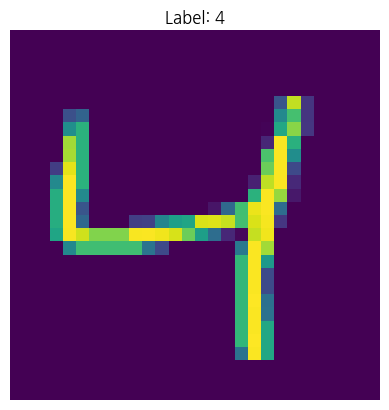

In [5]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [6]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [7]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3 (out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [8]:
# ANN 객체 생성
input_dim = 28 * 28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [9]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.15522518754005432  Accuracy: 96.3416976928711 %
Iteration: 1000  Loss: 0.05652862787246704  Accuracy: 96.88655090332031 %
Iteration: 1500  Loss: 0.04578479379415512  Accuracy: 97.48978424072266 %
Iteration: 2000  Loss: 0.1450965255498886  Accuracy: 97.56761932373047 %
Iteration: 2500  Loss: 0.09400014579296112  Accuracy: 97.80113220214844 %
Iteration: 3000  Loss: 0.08945272117853165  Accuracy: 98.03463745117188 %
Iteration: 3500  Loss: 0.06555011868476868  Accuracy: 98.26814270019531 %
Iteration: 4000  Loss: 0.04084727540612221  Accuracy: 98.34598541259766 %
Iteration: 4500  Loss: 0.04169783741235733  Accuracy: 98.46273803710938 %


#### **ANN 학습 결과**

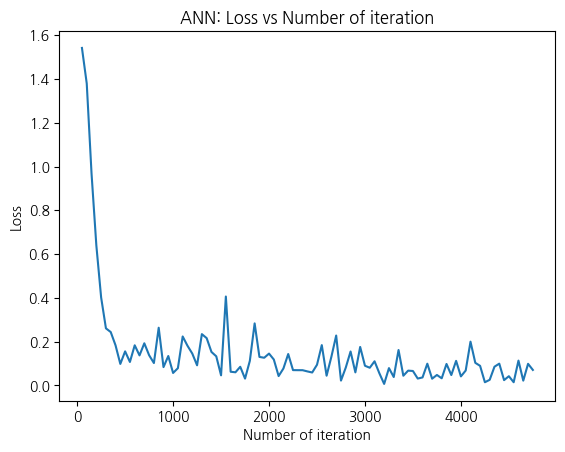

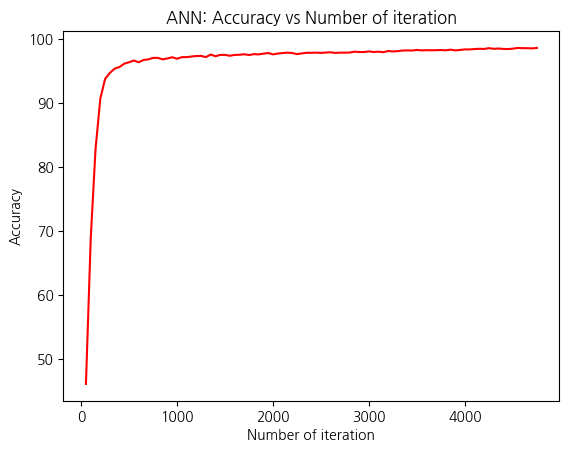

In [10]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- 시작 loss가 1.6 근처(ln 5)인 것을 통해 학습 전 5개 클래스를 무작위로 찍는 상태인 것을 알 수 있다.
- 1500번 iteration에서 loss가 1.6에서 0.2로 급락한 뒤 완만해지는 것을 관찰할 수 있다
- accuracy는 약 98%에서 정체된다
- loss 곡선이 흔들리는 것을 관찰할 수 있는데, loss 값을 전체 평균이 아닌 해당 순간의 한 배치 loss를 기록하고 있기 때문임을 알 수 있다


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [22]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import time

def train_eval(hidden_dim=150, learning_rate=0.02, num_epochs=3, seed=42, log_every=50):
  torch.manual_seed(seed)

  model = ANNModel(28*28, hidden_dim, 5)
  loss_ftn = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  def evaluate():
    correct = total = 0
    model.eval()
    with torch.no_grad():
      for im, lb in test_loader:
        pred = model(im.view(-1, 28*28)).argmax(dim=1)
        total += lb.size(0)
        correct += (pred == lb).sum().item()
    model.train()
    return 100 * correct / total

  count, iters, losses, accs = 0, [], [], []
  t0 = time.time()

  for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
      train = images.view(-1, 28*28)
      optimizer.zero_grad()
      outputs = model(train)
      loss = loss_ftn(outputs, labels)
      loss.backward()
      optimizer.step()
      count+=1

      if count % log_every == 0:
        iters.append(count)
        losses.append(loss.item())
        accs.append(evaluate())

  if not iters or iters[-1] != count:
    iters.append(count); losses.append(loss.item()); accs.append(evaluate())

  return {"iters": iters, "losses": losses, "accs": accs,
              "final_acc": accs[-1], "best_acc": max(accs),
              "n_params": sum(p.numel() for p in model.parameters()),
              "sec": round(time.time() - t0, 1)}

hidden_dims= [50, 100, 150, 200]
results_hd= {}

for hd in hidden_dims:
  results_hd[hd] = train_eval(hidden_dim=hd, learning_rate=0.02, num_epochs=3)
  r = results_hd[hd]
  print(f"hidden_dim={hd:4d} | 파라미터 {r['n_params']:>7,} | "
          f"최종 acc {r['final_acc']:.2f}% | 최고 acc {r['best_acc']:.2f}% | {r['sec']}초")


hidden_dim=  50 | 파라미터  44,605 | 최종 acc 97.45% | 최고 acc 97.45% | 28.9초
hidden_dim= 100 | 파라미터  99,205 | 최종 acc 97.30% | 최고 acc 97.37% | 28.9초
hidden_dim= 150 | 파라미터 163,805 | 최종 acc 97.37% | 최고 acc 97.47% | 30.6초
hidden_dim= 200 | 파라미터 238,405 | 최종 acc 97.53% | 최고 acc 97.53% | 30.0초


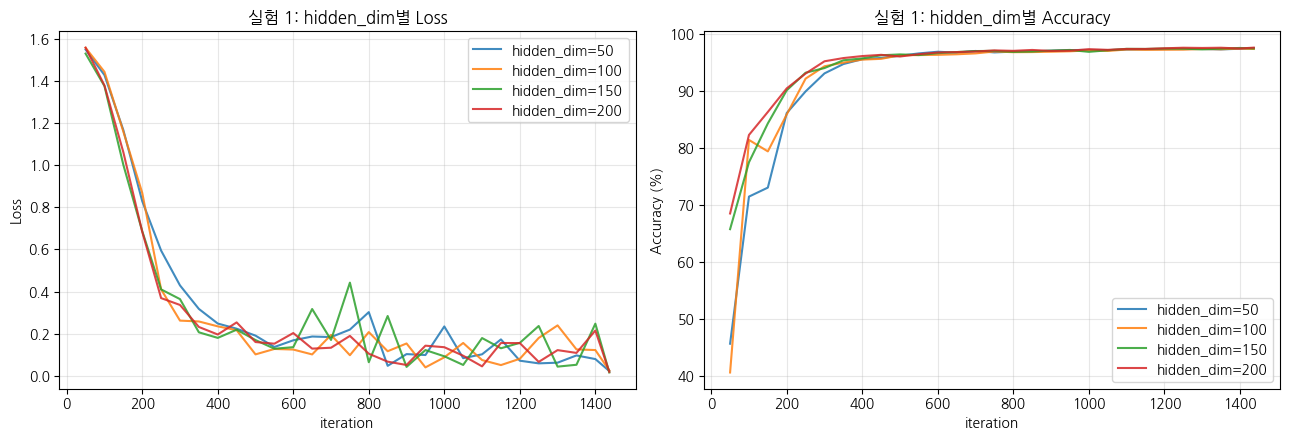

 hidden_dim |      파라미터 |   최종 acc |   최고 acc |    학습시간
----------------------------------------------------------
         50 |    44,605 |   97.45% |   97.45% |   32.5초
        100 |    99,205 |   97.30% |   97.37% |   29.7초
        150 |   163,805 |   97.37% |   97.47% |   42.2초
        200 |   238,405 |   97.53% |   97.53% |   31.2초


In [12]:
# 실험 1 모델 학습 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for hd in hidden_dims:
    r = results_hd[hd]
    axes[0].plot(r["iters"], r["losses"], label=f"hidden_dim={hd}", alpha=.85)
    axes[1].plot(r["iters"], r["accs"],   label=f"hidden_dim={hd}", alpha=.85)

axes[0].set_xlabel("iteration"); axes[0].set_ylabel("Loss"); axes[0].set_title("실험 1: hidden_dim별 Loss")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("실험 1: hidden_dim별 Accuracy")
for ax in axes: ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# 요약 표 (이 숫자를 서술형 답안에 인용하세요)
print(f"{'hidden_dim':>11} | {'파라미터':>9} | {'최종 acc':>8} | {'최고 acc':>8} | {'학습시간':>7}")
print("-" * 58)
for hd in hidden_dims:
    r = results_hd[hd]
    print(f"{hd:>11} | {r['n_params']:>9,} | {r['final_acc']:>7.2f}% | {r['best_acc']:>7.2f}% | {r['sec']:>6}초")

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- hidden_dim이 늘어날수록 파라미터 수가 비례하며 커짐
- hidden_dim이 증가할수록 학습 시간이 늘어나나, 증가하는 시간의 비용에 비해 정확도는 큰 차이를 보이지 않음

In [23]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.005, 0.01, 0.05, 0.1]
results_lr = {}

for lr in learning_rates:
    results_lr[lr] = train_eval(hidden_dim=150, learning_rate=lr, num_epochs=3)
    r = results_lr[lr]
    print(f"lr={lr:<6} | 최종 acc {r['final_acc']:.2f}% | 최고 acc {r['best_acc']:.2f}% | "
          f"마지막 loss {r['losses'][-1]:.4f}")

lr=0.005  | 최종 acc 95.33% | 최고 acc 95.33% | 마지막 loss 0.1029
lr=0.01   | 최종 acc 96.75% | 최고 acc 96.87% | 마지막 loss 0.0236
lr=0.05   | 최종 acc 98.13% | 최고 acc 98.13% | 마지막 loss 0.0174
lr=0.1    | 최종 acc 98.72% | 최고 acc 98.72% | 마지막 loss 0.0121


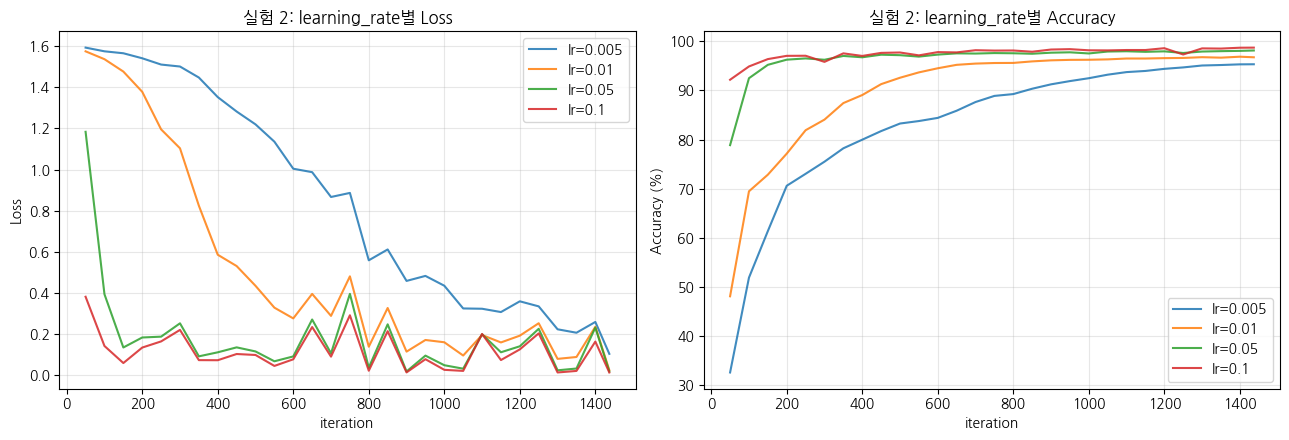

     lr |   최종 acc |   최고 acc |    마지막 loss
---------------------------------------------
  0.005 |   95.33% |   95.33% |      0.1029
   0.01 |   96.75% |   96.87% |      0.0236
   0.05 |   98.13% |   98.13% |      0.0174
    0.1 |   98.72% |   98.72% |      0.0121


In [24]:
# 실험 2 모델 학습 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for lr in learning_rates:
    r = results_lr[lr]
    axes[0].plot(r["iters"], r["losses"], label=f"lr={lr}", alpha=.85)
    axes[1].plot(r["iters"], r["accs"],   label=f"lr={lr}", alpha=.85)

axes[0].set_xlabel("iteration"); axes[0].set_ylabel("Loss"); axes[0].set_title("실험 2: learning_rate별 Loss")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("실험 2: learning_rate별 Accuracy")
for ax in axes: ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"{'lr':>7} | {'최종 acc':>8} | {'최고 acc':>8} | {'마지막 loss':>11}")
print("-" * 45)
for lr in learning_rates:
    r = results_lr[lr]
    print(f"{lr:>7} | {r['final_acc']:>7.2f}% | {r['best_acc']:>7.2f}% | {r['losses'][-1]:>11.4f}")

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



----
**[답변]**
- lr이 작을 때 loss가 안정적으로 내려가지만 속도가 느리다.
- lr이 클 때 초반 하강이 가파르지만 후반으로 갈수록 loss 곡선의 진동이 커진다
- lr은 속도와 안정성 트레이드오프를 조절하는 걸 알 수 있다

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()# 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4* 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [19]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [20]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images_t, labels_t in test_loader:
                    # 모델 예측 수행
                    outputs_t = model(images_t)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs_t, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels_t.size(0)
                    correct += (predicted == labels_t).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5232395901342772
Epoch 2, Loss: 0.12415770897330689
Epoch 3, Loss: 0.1006315884370909
Epoch 4, Loss: 0.0859517322227141
Epoch 5, Loss: 0.0754671688670378
Epoch 6, Loss: 0.06766778050527163
Epoch 7, Loss: 0.06038603992400679
Epoch 8, Loss: 0.054573005901373504
Epoch 9, Loss: 0.04981393801264216
Epoch 10, Loss: 0.04569711488873809
Epoch 11, Loss: 0.04342019306942976
Epoch 12, Loss: 0.04010665029679116
Epoch 13, Loss: 0.03854107998283813
Epoch 14, Loss: 0.03609411275239821
Epoch 15, Loss: 0.03430319108780559
Epoch 16, Loss: 0.032884342478365115
Epoch 17, Loss: 0.031652060466964824
Epoch 18, Loss: 0.030271941496279004
Epoch 19, Loss: 0.029098745624560062
Epoch 20, Loss: 0.028226392419954338


#### **CNN 학습 결과**

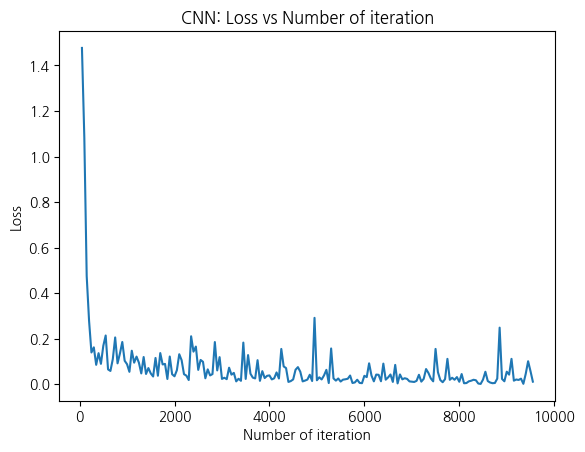

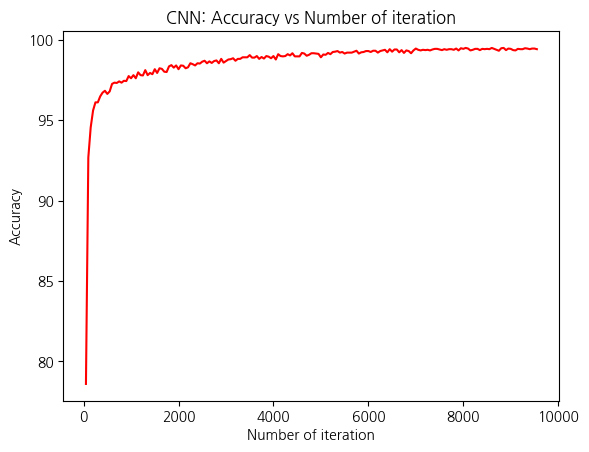

In [21]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN은 입력을 일차원 벡터로 flatten한 뒤 각 뉴런이 앞 층의 모든 뉴런과 연결된 fully connected 층을 여러 겹 쌓은 모델이다. 층마다 ReLU, Tahn, ELU와 같은 비선형 활성화 함수를 넣어야 깊이가 의미를 갖는다. 이미지를 784차원 벡터로 필 때 어떤 필섹이 어떤 픽셀 옆에 있었는지를 나타내는 공간 정보를 잃는다
- ANN은 이미지를 (1, 28, 28) 형태 그대로 받아, 작은 커널(5x5)이 이미지를 훑으며 feature map을 만든다. MaxPooling은 feature map의 크기를 줄여 계산량을 낮추고, 숫자가 한 두 픽셀 밀려도 같은 값이 나오게 해 위치 변화에 둔감하게 만든다.

|항목         | ANN       | CNN     |
| -------| -------| -------|
|입력 형태|(N, 784) 1D 벡터| (N, 1, 28, 28) 4D|
|파라미터수| 163,805|15813|
|공간정보|소실|보존|
|가중치 공유|없음|있음|
- CNN은 ANN에 비해 사용하는 파라미터 1/10배임에도 정확도가 더 높았으며, 이 결과는 가중치 공유 때문인 것을 알 수 있다
- 수렴 속도는 CNN이 더 빨랐다
- MNIST는 0-4 비교적 쉬운 문제기에 두 모델의 최종 정확도 격차는 그래프 육안상 많이 차이나지 않았다. 클래스를 늘리거나 더욱 복잡한 이미지로 갈수록 격차가 늘어날 것으로 생각된다.
